In [143]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, when, avg, expr, log1p, expm1, abs
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.types import FloatType, IntegerType
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv


In [102]:
spark=SparkSession.builder.appName('Inspecting_healthcare').getOrCreate()

In [103]:
load_dotenv()
#Create the folder with the csv files and store it in your preferred locaton in your PC. Do not push the csv files on github LOL.

base_path=os.getenv('FOLDER_PATH')

url=base_path+"/final_data.csv" 
data=spark.read.option('header','true').option('inferSchema','true').csv(url)

In [104]:
data.show()

+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|                  1|   00100|             N|            F|              239|      219|    322.0|               322|  1069.9324224|2013|
|                  1|   00103|             N|            F|              515|     2394|   4206.0|              4206|  610.75801474|2013|
|                  1|   00104|             N|            F|              286|      309|   3103.0|              3103|  396.53074444|2013|
|                  1|   00120|             N|            F|              363|      615|    986.0|               985|  711.17103448|2013|
|                  1|   00124|           

In [105]:
data.printSchema()

#checking...
before_dropping=data.count()
data=data.na.drop()
after_dropping=data.count()

print('Dropped rows with null values',before_dropping-after_dropping)


root
 |-- Rndrng_Prvdr_Geo_Cd: integer (nullable = true)
 |-- HCPCS_Cd: string (nullable = true)
 |-- HCPCS_Drug_Ind: string (nullable = true)
 |-- Place_Of_Srvc: string (nullable = true)
 |-- Tot_Rndrng_Prvdrs: integer (nullable = true)
 |-- Tot_Benes: integer (nullable = true)
 |-- Tot_Srvcs: double (nullable = true)
 |-- Tot_Bene_Day_Srvcs: integer (nullable = true)
 |-- Avg_Sbmtd_Chrg: double (nullable = true)
 |-- Year: integer (nullable = true)

Dropped rows with null values 0


In [106]:
#Defining Columns
total_cat=['HCPCS_Cd', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
num_cols=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
low_cardy=[]
high_cardy=[]



for column in total_cat:
    
    data=data.withColumn(column,col(column).cast('string')) #casting to treat as category 

    dis_val=data.select(column).distinct().count()

    if dis_val<60:
        low_cardy.append(column)
    else:
        high_cardy.append(column)

    print(f'Column: {column} number of unique values: {dis_val}')

print(f'\nLow cardinality columns: {low_cardy}')
print(f'High cardinality columns: {high_cardy}')

Column: HCPCS_Cd number of unique values: 9966
Column: HCPCS_Drug_Ind number of unique values: 2
Column: Place_Of_Srvc number of unique values: 2
Column: Rndrng_Prvdr_Geo_Cd number of unique values: 56
Column: Year number of unique values: 11

Low cardinality columns: ['HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
High cardinality columns: ['HCPCS_Cd']


In [ ]:
# freq = X_train.groupBy("HCPCS_Cd").count()
# rare = freq.filter(F.col("count") < 20).select("HCPCS_Cd")
# rare.show()

Data Exploration on HCPCS_Cd

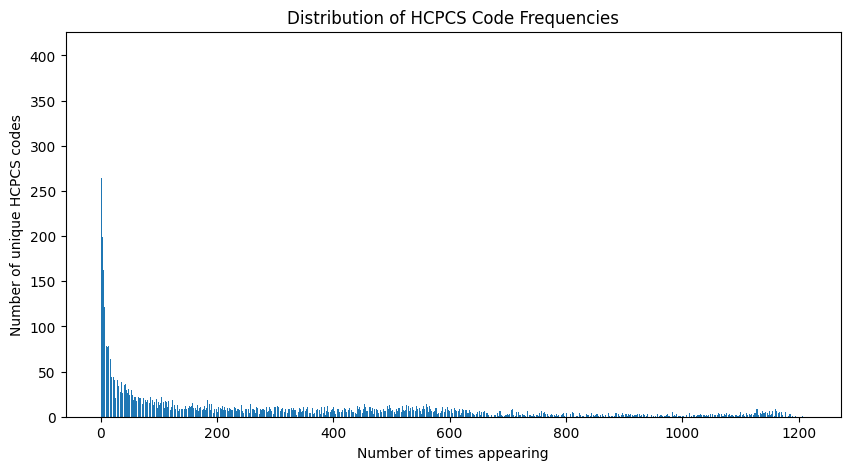

In [150]:
unique_count = data.groupBy("HCPCS_Cd").count()

groupCount = (
    unique_count
    .groupBy("count")
    .agg(count("*").alias("num_codes"))
    .orderBy("count")
)

pdf = groupCount.toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf["count"], pdf["num_codes"])
plt.xlabel("Number of times appearing")
plt.ylabel("Number of unique HCPCS codes")
plt.title("Distribution of HCPCS Code Frequencies")
plt.show()

# groupCount.show()

Based on the last graphic, anything under 50 ocurrences is rare

In [155]:
common_codes=unique_count.filter(col('count')>50).orderBy("count")

common_codes.show()

+--------+-----+
|HCPCS_Cd|count|
+--------+-----+
|   33305|   51|
|   28260|   51|
|   35013|   51|
|   94400|   51|
|   J1440|   51|
|   01850|   51|
|   44212|   51|
|   43271|   51|
|   53215|   51|
|   24140|   51|
|   J3488|   51|
|   78428|   51|
|   23406|   51|
|   J1240|   51|
|   81319|   51|
|   J0833|   51|
|   81313|   51|
|   30110|   51|
|   0330T|   51|
|   87803|   51|
+--------+-----+
only showing top 20 rows


Preprocessing

In [107]:
# X=data.select('*')
X=data.sample(fraction=0.05,seed=42)

for column in num_cols:
    X=X.withColumn(column,log1p(col(column)))

X_train,X_test=X.randomSplit([0.8, 0.2], seed=42)

print("Train:", X_train.count())
print("Test:", X_test.count())

Train: 225310
Test: 56230


Pipeline Construction

In [125]:

#indexing
string_indexer=StringIndexer(inputCols=total_cat,
                             outputCols=[f'{c}_idx' for c in total_cat],
                             handleInvalid='keep')

ohencoder=OneHotEncoder(inputCols=[f'{c}_idx' for c in low_cardy],
                        outputCols=[f'{c}_ohe' for c in low_cardy],
                        handleInvalid='keep'
)

#vectorize to scale
scale_assembler=VectorAssembler(inputCols=num_cols,
                                outputCol='num_features')

#scaling #check if log transfor need to be used for the other columns not just the target!!!!!
scaler=StandardScaler(inputCol='num_features',
                      outputCol='scaled_num_features')
#vectorizing everything
assembler=VectorAssembler(
    inputCols=[f'{c}_ohe' for c in low_cardy]+[f'{c}_idx' for c in high_cardy]+['scaled_num_features'],
 outputCol='Features_Col'
)

evaluator=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
                              predictionCol='prediction',
                              metricName='rmse')


In [124]:
def sparl_model(model,param_grid,X_train,X_test):

    pipeline=Pipeline(stages=[
        string_indexer,
        ohencoder,
        scale_assembler,
        scaler,
        assembler,
        model])

    crossval = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,
        numFolds=5,
        seed=42
    )

    cv_model=crossval.fit(X_train) #best model
    test_predictions=cv_model.transform(X_test)
    test_rmse=evaluator.evaluate(test_predictions)

    return cv_model,test_predictions,test_rmse

models_results=[]


Linear Regression

In [127]:
lr=LinearRegression(featuresCol='Features_Col',
                    labelCol='Avg_Sbmtd_Chrg')

lr_grid = ParamGridBuilder() \
        .addGrid(lr.regParam, [0.0, 0.01, 0.1]) \
        .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
        .build()

lr_model,lr_preds,lr_rmse=sparl_model(lr,lr_grid,X_train,X_test)

print(f'rmse: {lr_rmse}')

rmse: 2143.126029936022


Random Forest

In [132]:
rf = RandomForestRegressor(featuresCol="Features_Col", labelCol="Avg_Sbmtd_Chrg")

rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

rf_model,rf_preds,rf_rmse=sparl_model(rf,rf_grid,X_train,X_test)

print(f'rmse: {rf_rmse}')

IllegalArgumentException: requirement failed: DecisionTree requires maxBins (= 32) to be at least as large as the number of values in each categorical feature, but categorical feature 75 has 8231 values. Consider removing this and other categorical features with a large number of values, or add more training examples.

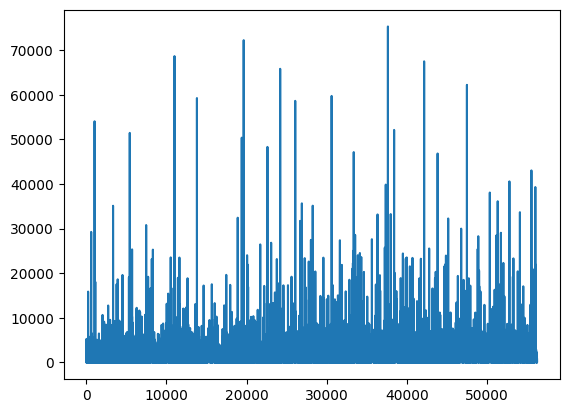

In [128]:
lr_preds=lr_preds.withColumn('Residuals',abs(col('Avg_Sbmtd_Chrg')-col('prediction')))
residuals=lr_preds.select('Residuals').toPandas()

plt.plot(range(len(residuals)),residuals)

Extra Stuff

In [115]:
#Utah:49
utah=X.filter(col('Rndrng_Prvdr_Geo_Cd')==49)

In [116]:
utah.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----+
|                 49|   00210|             N|            F| 4.499809670330265|  5.25227342804663| 5.318119993844216| 5.318119993844216|  2957.9300493|2013|
|                 49|   00211|             N|            F|3.9318256327243257| 4.174387269895637| 4.304065093204169| 4.304065093204169|  2046.7054795|2013|
|                 49|   00450|             N|            F| 3.367295829986474|3.4339872044851463|3.4965075614664802|3.4965075614664802|    1260.58125|2013|
|                 49|   00542|             N|            F|3.218

In [117]:
null_counts = X.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in X.columns
])

null_counts.show()

+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Year|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+
|                  0|       0|             0|            0|                0|        0|        0|                 0|             0|   0|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----+



array([[<Axes: title={'center': 'Tot_Rndrng_Prvdrs'}>]], dtype=object)

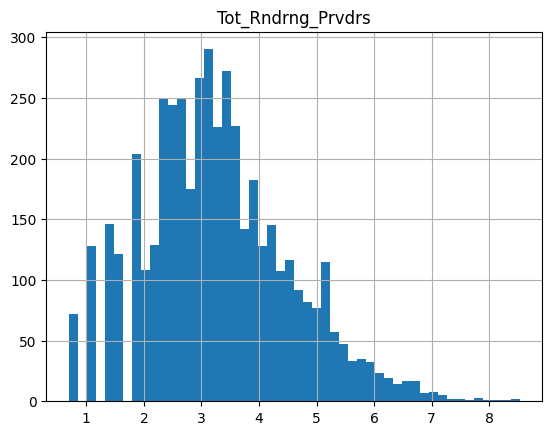

In [118]:
columns_scale=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
utah.select("Tot_Rndrng_Prvdrs").toPandas().hist(bins=50)

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

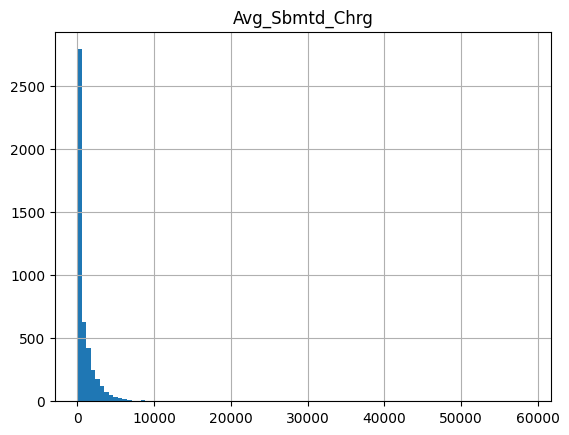

In [119]:
utah.select("Avg_Sbmtd_Chrg").toPandas().hist(bins=100)

In [120]:
utah.columns

['Rndrng_Prvdr_Geo_Cd',
 'HCPCS_Cd',
 'HCPCS_Drug_Ind',
 'Place_Of_Srvc',
 'Tot_Rndrng_Prvdrs',
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Bene_Day_Srvcs',
 'Avg_Sbmtd_Chrg',
 'Year']

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

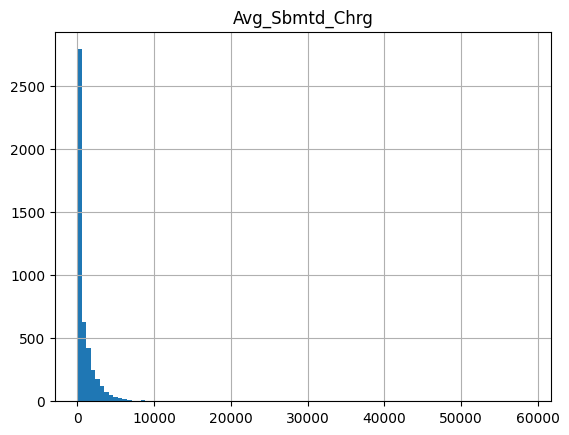

In [121]:
utah.select('Avg_Sbmtd_Chrg').toPandas().hist(bins=100)

In [122]:
utah.describe('Avg_Sbmtd_Chrg').show()

+-------+------------------+
|summary|    Avg_Sbmtd_Chrg|
+-------+------------------+
|  count|              4619|
|   mean| 959.4411180903968|
| stddev|1841.3373858104603|
|    min|              0.01|
|    max|          58758.65|
+-------+------------------+

